In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [116]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
pd.set_option(
    "display.max_colwidth", 12,
    "display.max_rows", 12,
    "display.max_columns", 50,
    "display.precision", 4
)
plt.style.use('MyStyle.txt')
cm = 1/2.54
palette = ["#3F3517",  '#CE2E31', '#C96F6B', '#CCA464', '#F8D768', '#F0DCD4']

In [152]:
import utils.shape_extractor

In [153]:
shapefile_path = "./data/SA3_SHP/SA3_2021_AUST_GDA2020.shp"
gdf, gdf_m = utils.shape_extractor.final_gdf_creator(shapefile_path)
gdf

,SA3_CODE21,SA3_NAME21,CHG_FLAG21,CHG_LBL21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry,centroid,furthest_dist_m
0,10102,Queanbeyan,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,6511.3971,http://l...,POLYGON ...,POINT (1...,0.6643
1,10103,Snowy Mo...,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,14284.5857,http://l...,POLYGON ...,POINT (1...,0.9218
2,10104,South Coast,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,9864.4876,http://l...,MULTIPOL...,POINT (1...,1.1120
3,10105,Goulburn...,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,9099.9087,http://l...,POLYGON ...,POINT (1...,0.8350
4,10106,Young - ...,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,12135.8653,http://l...,POLYGON ...,POINT (1...,1.0554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,90103,Jervis Bay,0,No change,901,Other Te...,9OTER,Other Te...,9,Other Te...,AUS,Australia,67.2296,http://l...,MULTIPOL...,POINT (1...,0.1034
355,90104,Norfolk ...,0,No change,901,Other Te...,9OTER,Other Te...,9,Other Te...,AUS,Australia,38.6510,http://l...,MULTIPOL...,POINT (1...,0.0988
356,99797,Migrator...,0,No change,997,Migrator...,99799,Migrator...,9,Other Te...,AUS,Australia,NaN,http://l...,None,None,NaN
357,99999,No usual...,0,No change,999,No usual...,99499,No usual...,9,Other Te...,AUS,Australia,NaN,http://l...,None,None,NaN


In [154]:
gdf.describe()

,AREASQKM21,furthest_dist_m
count,340.0000,340.0000
mean,22612.0439,0.6559
std,87470.5180,1.2253
min,10.6577,0.0267
25%,56.1319,0.0691
50%,292.2250,0.1790
75%,5521.3837,0.6888
max,714524.7709,8.1140


In [155]:
gdf.crs

<Geographic 2D CRS: EPSG:7844>
Name: GDA2020
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Australia including Lord Howe Island, Macquarie Island, Ashmore and Cartier Islands, Christmas Island, Cocos (Keeling) Islands, Norfolk Island. All onshore and offshore.
- bounds: (93.41, -60.55, 173.34, -8.47)
Datum: Geocentric Datum of Australia 2020
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [156]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   SA3_CODE21       359 non-null    object  
 1   SA3_NAME21       359 non-null    object  
 2   CHG_FLAG21       359 non-null    object  
 3   CHG_LBL21        359 non-null    object  
 4   SA4_CODE21       359 non-null    object  
 5   SA4_NAME21       359 non-null    object  
 6   GCC_CODE21       359 non-null    object  
 7   GCC_NAME21       359 non-null    object  
 8   STE_CODE21       359 non-null    object  
 9   STE_NAME21       359 non-null    object  
 10  AUS_CODE21       359 non-null    object  
 11  AUS_NAME21       359 non-null    object  
 12  AREASQKM21       340 non-null    float64 
 13  LOCI_URI21       359 non-null    object  
 14  geometry         340 non-null    geometry
 15  centroid         340 non-null    geometry
 16  furthest_dist_m  340 non-null    flo

In [157]:
gdf.head()

,SA3_CODE21,SA3_NAME21,CHG_FLAG21,CHG_LBL21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry,centroid,furthest_dist_m
0,10102,Queanbeyan,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,6511.3971,http://l...,POLYGON ...,POINT (1...,0.6643
1,10103,Snowy Mo...,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,14284.5857,http://l...,POLYGON ...,POINT (1...,0.9218
2,10104,South Coast,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,9864.4876,http://l...,MULTIPOL...,POINT (1...,1.1120
3,10105,Goulburn...,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,9099.9087,http://l...,POLYGON ...,POINT (1...,0.8350
4,10106,Young - ...,0,No change,101,Capital ...,1RNSW,Rest of NSW,1,New Sout...,AUS,Australia,12135.8653,http://l...,POLYGON ...,POINT (1...,1.0554


In [158]:
print("\n=== Missing Values per Column ===")
print(gdf.isna().sum())


=== Missing Values per Column ===
SA3_CODE21          0
SA3_NAME21          0
CHG_FLAG21          0
CHG_LBL21           0
SA4_CODE21          0
                   ..
AREASQKM21         19
LOCI_URI21          0
geometry           19
centroid           19
furthest_dist_m    19
Length: 17, dtype: int64


In [159]:
print("\n=== Number of Unique Values per Column ===")
print(gdf.nunique())


=== Number of Unique Values per Column ===
SA3_CODE21         359
SA3_NAME21         359
CHG_FLAG21           3
CHG_LBL21            3
SA4_CODE21         108
                  ... 
AREASQKM21         340
LOCI_URI21         359
geometry           340
centroid           340
furthest_dist_m    340
Length: 17, dtype: int64


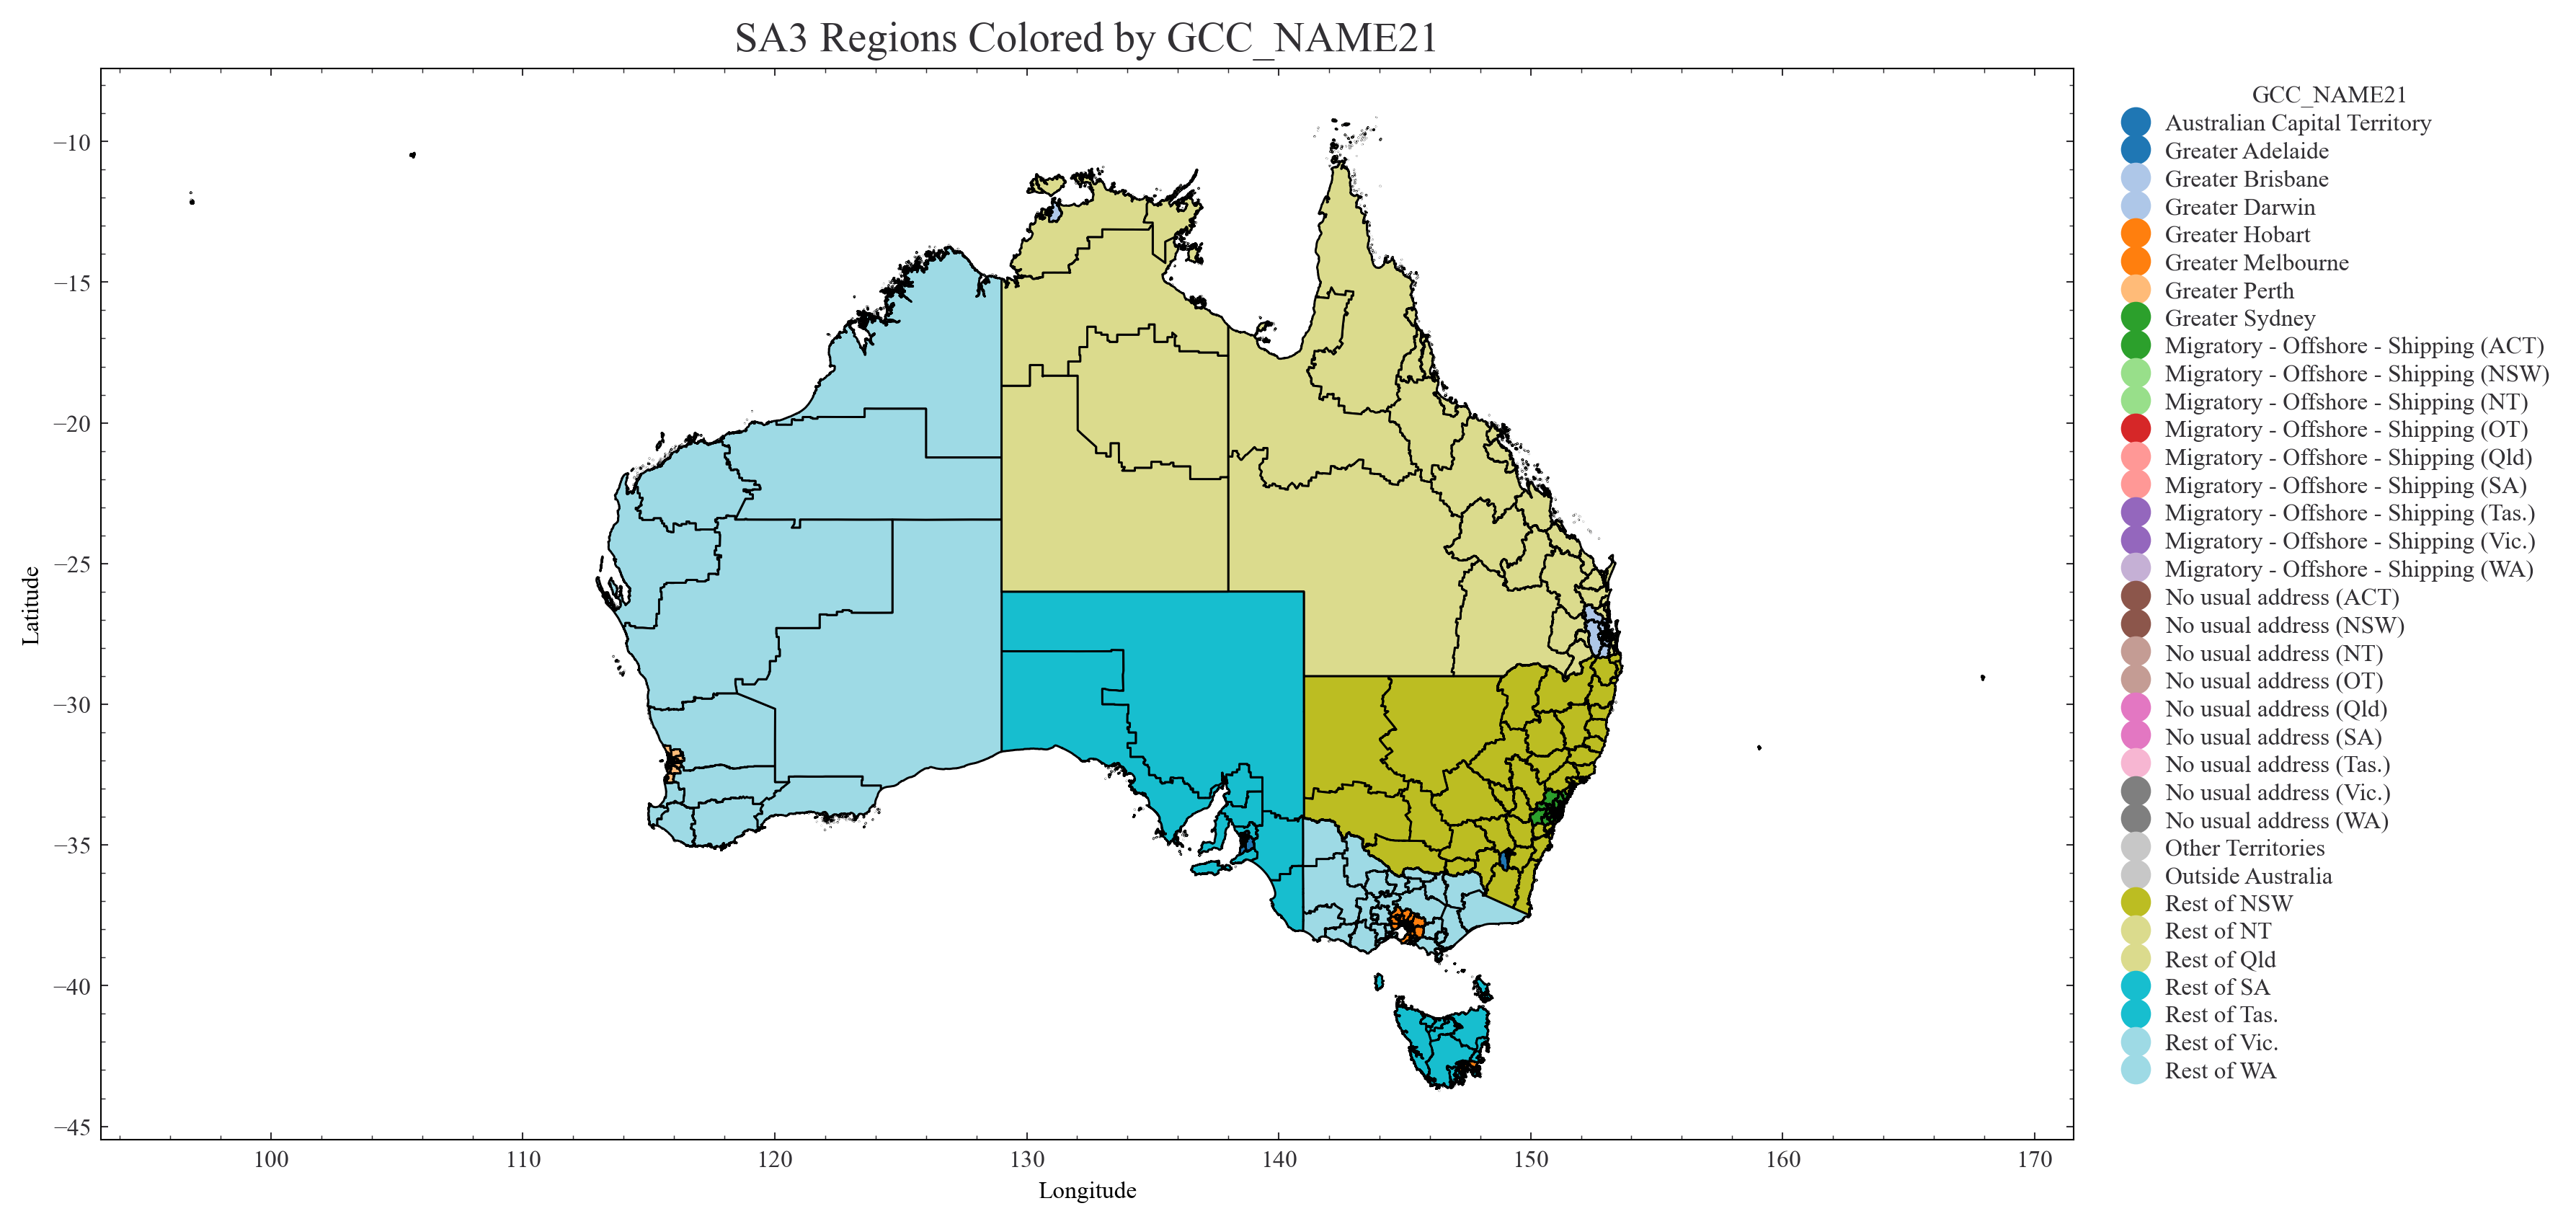

In [160]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot with colors by GCC_NAME21
gdf.plot(column="GCC_NAME21", ax=ax, legend=True, cmap="tab20")

# Move the legend outside the map
leg = ax.get_legend()
leg.set_bbox_to_anchor((1.25, 1))  # Move to right side
leg.set_title("GCC_NAME21")

# Titles and formatting
ax.set_title("SA3 Regions Colored by GCC_NAME21", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


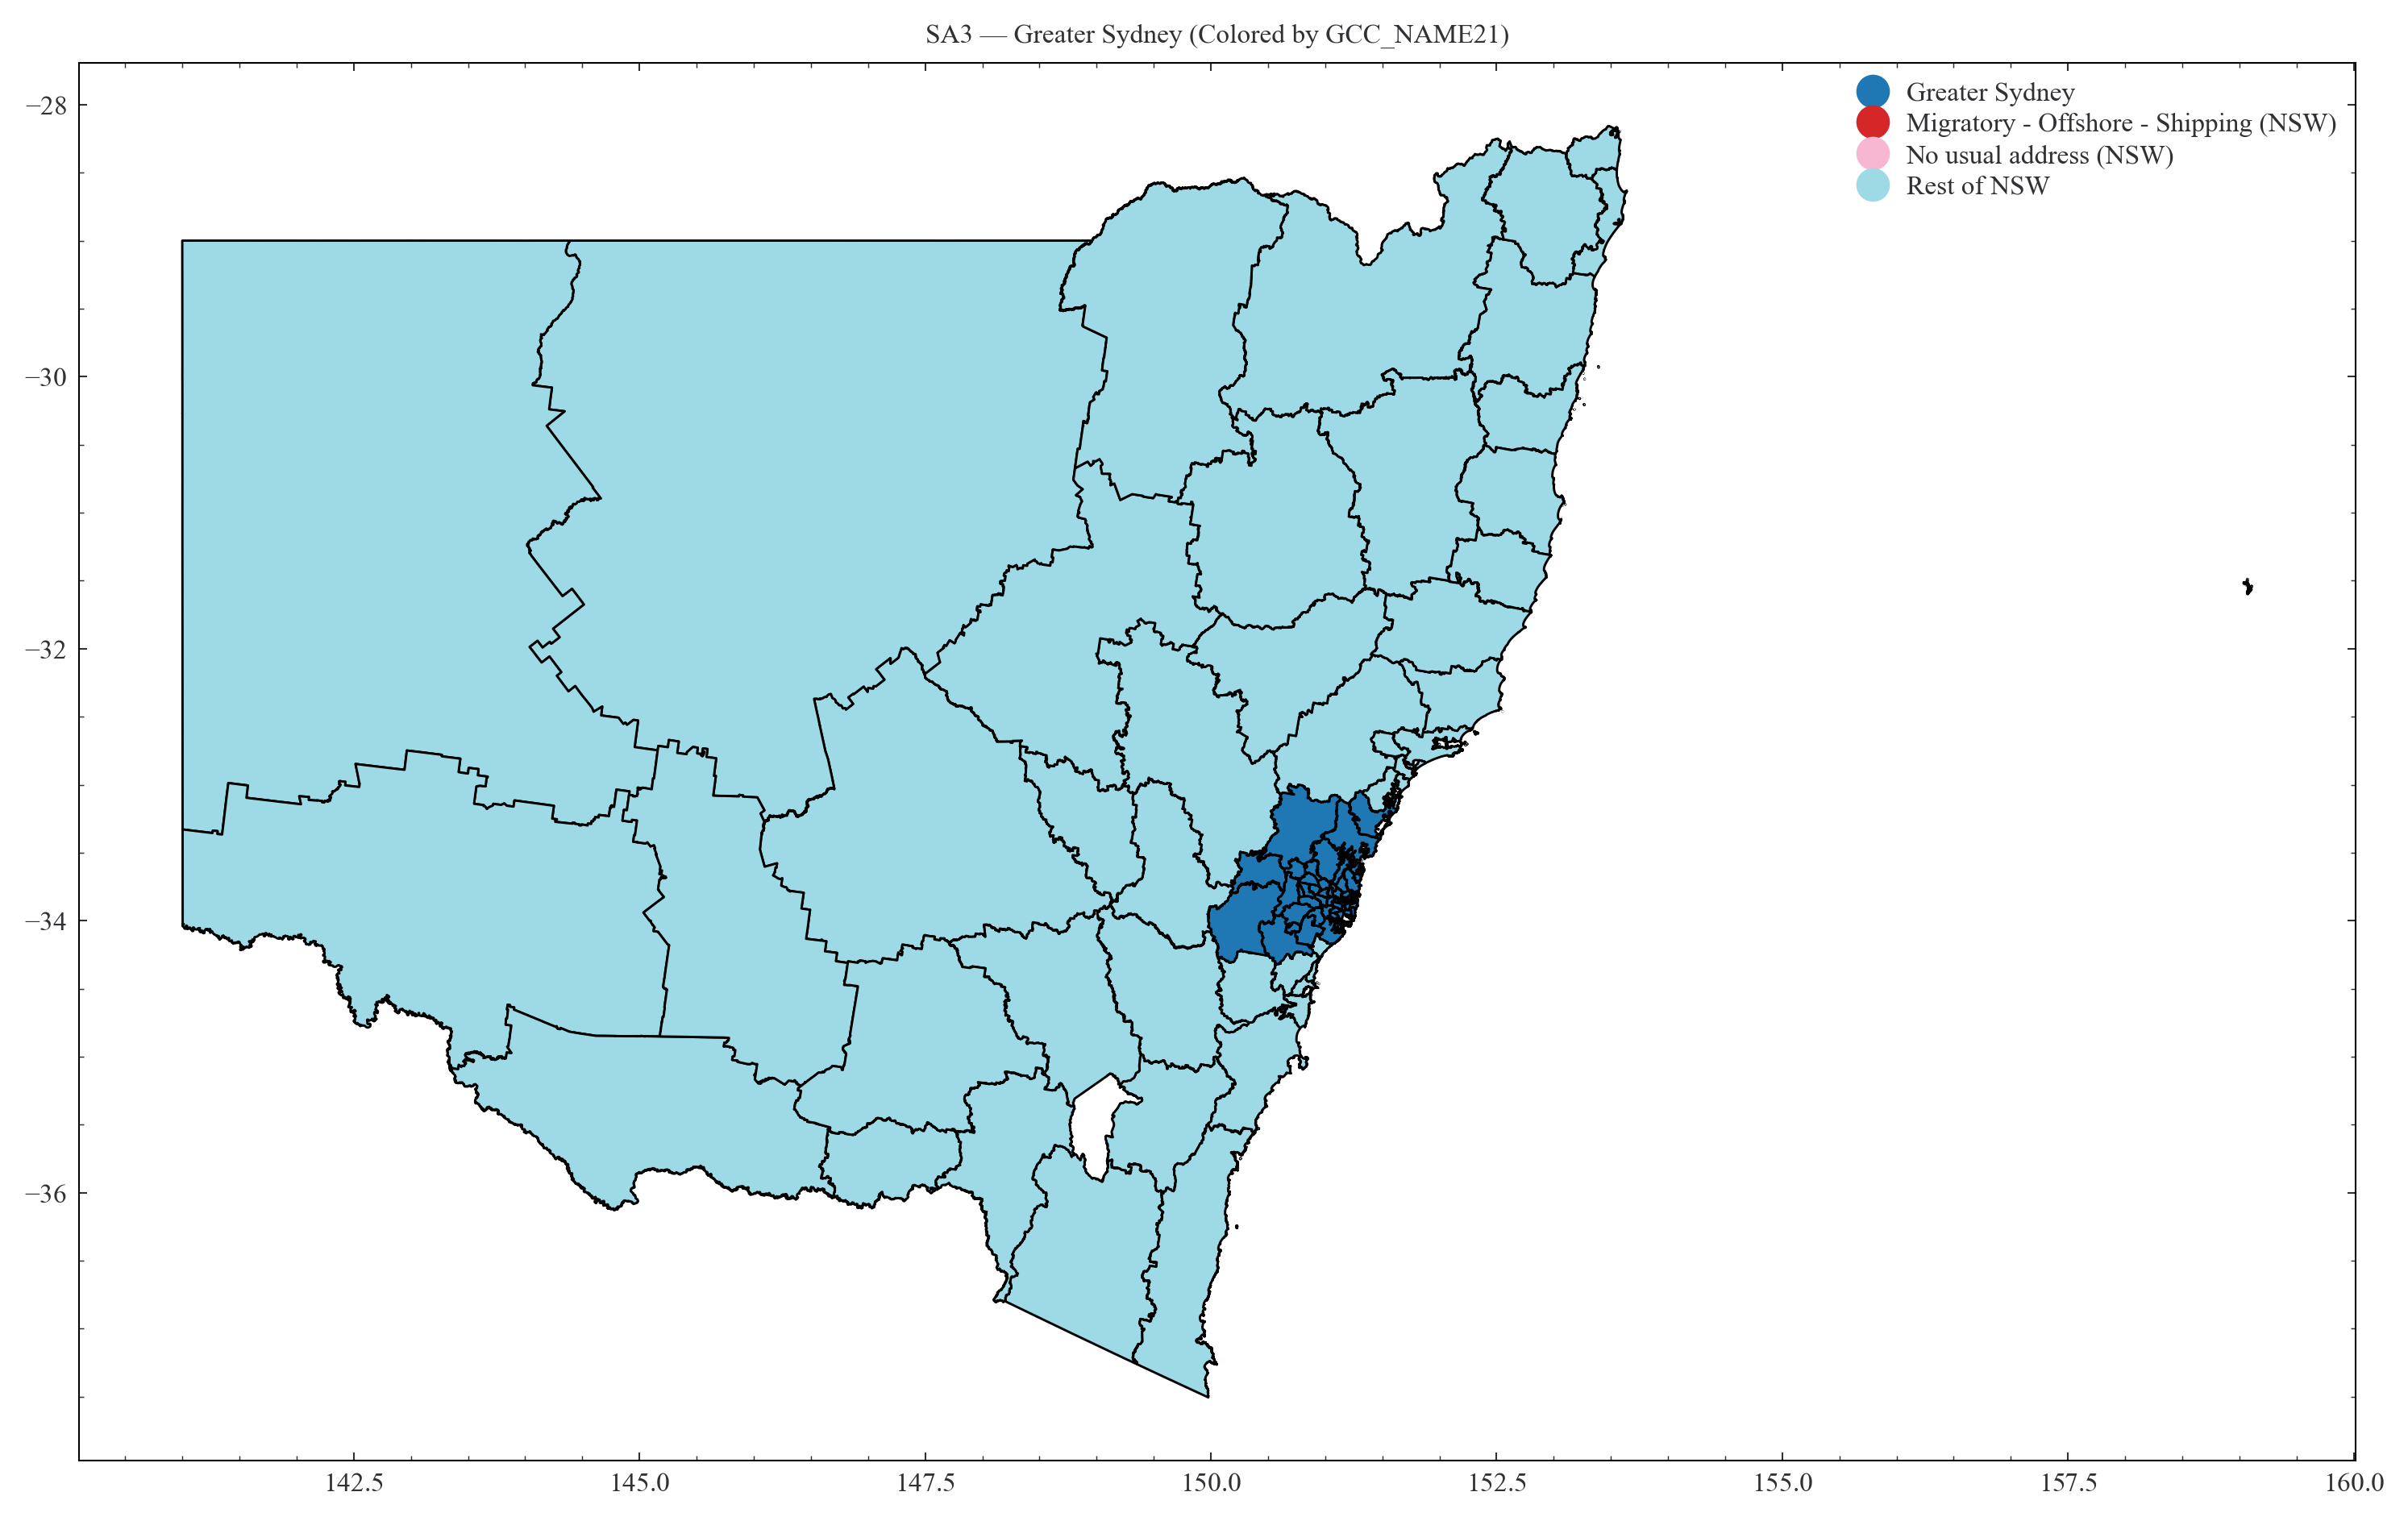

In [161]:
gdf_nsw = gdf[gdf["GCC_NAME21"].str.contains("Sydney", case=False, na=False) | gdf["GCC_NAME21"].str.contains("NSW", case=False, na=False)]
gdf_nsw.plot(column="GCC_NAME21", figsize=(10, 8), legend=True, cmap="tab20")
plt.title("SA3 — Greater Sydney (Colored by GCC_NAME21)")
plt.tight_layout()
plt.show()


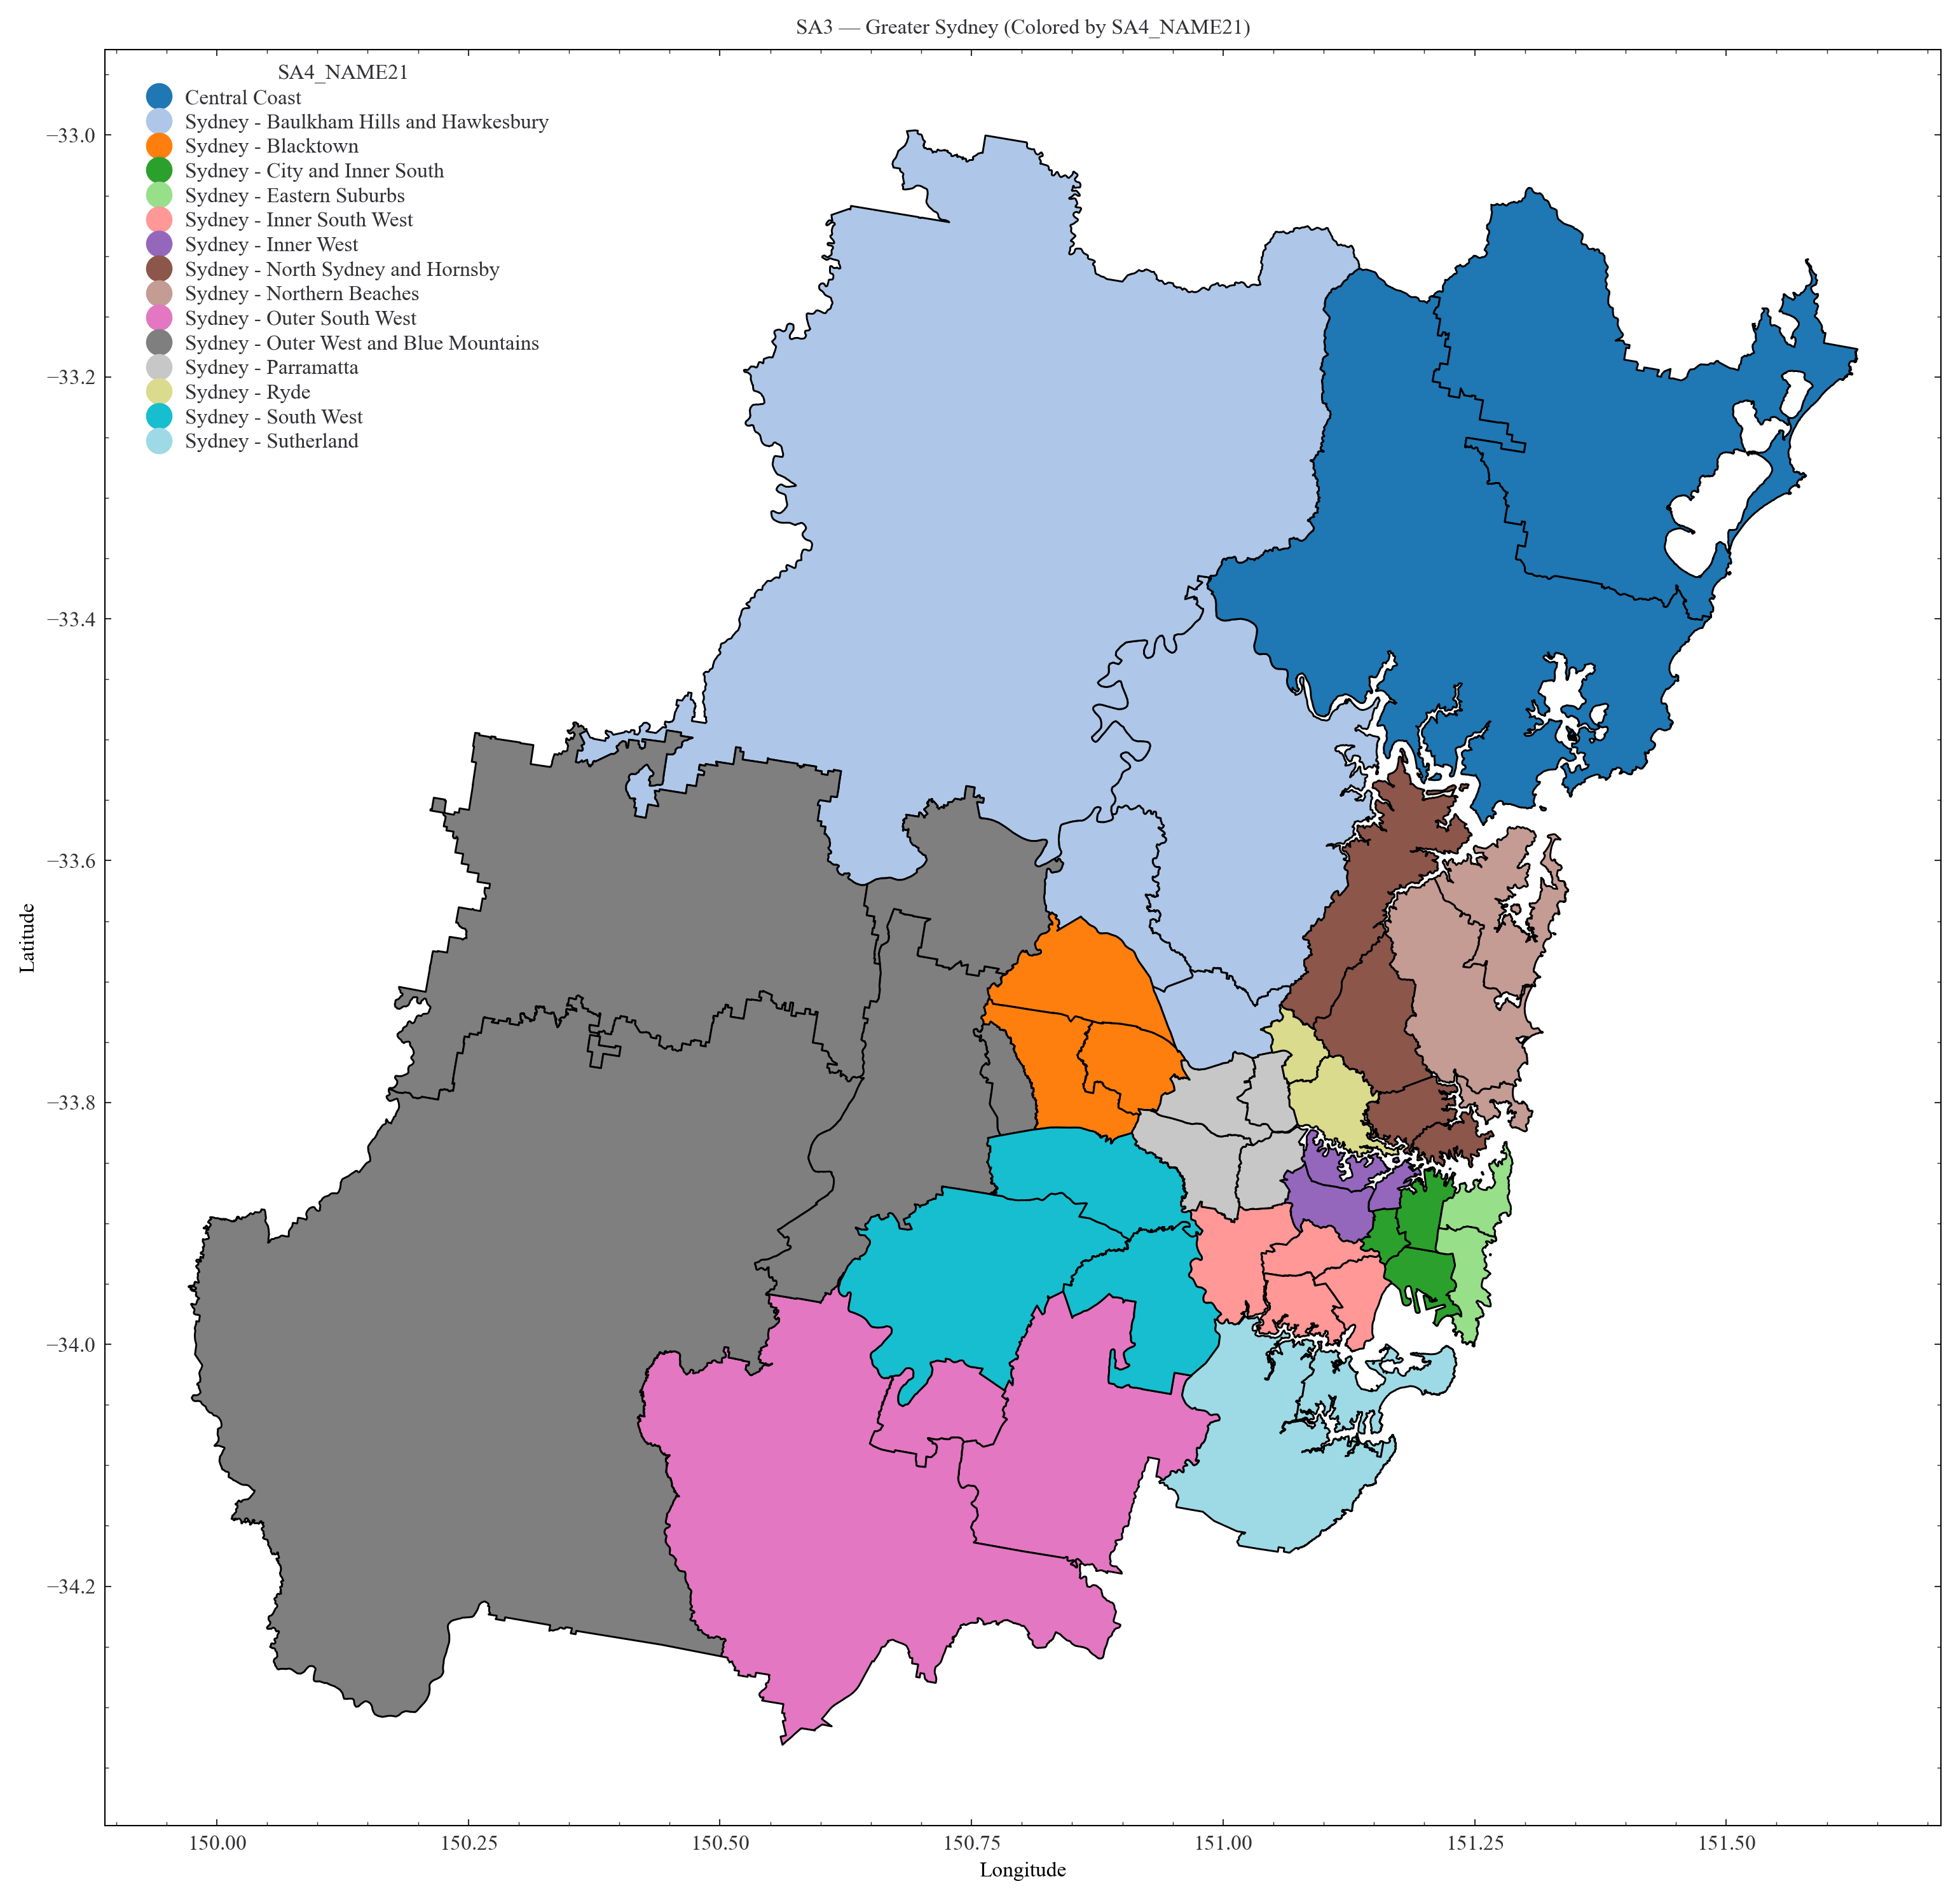

In [162]:
gdf_syd = gdf[gdf["GCC_NAME21"].str.contains("Sydney", case=False, na=False)]

fig, ax = plt.subplots(figsize=(12, 10))

# Plot with colors by GCC_NAME21
gdf_syd.plot(column="SA4_NAME21", legend=True, cmap="tab20", ax=ax)

# Move the legend outside the map
leg = ax.get_legend()
leg.set_bbox_to_anchor((0.25, 1))  # Move to right side
leg.set_title("SA4_NAME21")

plt.title("SA3 — Greater Sydney (Colored by SA4_NAME21)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


In [163]:
# Bounding box and total area
print("\n=== Bounding Box ===")
print(gdf_syd.total_bounds)  # [minx, miny, maxx, maxy]


print("\n=== Area Stats (sq km) ===")
print(gdf_syd['AREASQKM21'].describe())



=== Bounding Box ===
[149.97189159 -34.33116127 151.63055248 -32.99605649]

=== Area Stats (sq km) ===
count      47.0000
mean      263.1635
std       531.4453
min        10.6577
25%        31.4480
50%        68.6675
75%       164.0255
max      2492.0101
Name: AREASQKM21, dtype: float64


In [164]:
max_row = gdf_syd.loc[gdf_syd["furthest_dist_m"].idxmax()]

print("=== Region with Farthest Vertex from Centroid ===")
print(f"SA3_NAME21: {max_row['SA3_NAME21']}")
print(f"GCC_NAME21: {max_row['GCC_NAME21']}")
print(f"Max distance from centroid to furthest vertex: {max_row['furthest_dist_m']:.2f} meters")

=== Region with Farthest Vertex from Centroid ===
SA3_NAME21: Hawkesbury
GCC_NAME21: Greater Sydney
Max distance from centroid to furthest vertex: 0.47 meters


In [165]:
gdf_syd.head()

,SA3_CODE21,SA3_NAME21,CHG_FLAG21,CHG_LBL21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry,centroid,furthest_dist_m
5,10201,Gosford,0,No change,102,Central ...,1GSYD,Greater ...,1,New Sout...,AUS,Australia,988.3863,http://l...,MULTIPOL...,POINT (1...,0.2688
6,10202,Wyong,0,No change,102,Central ...,1GSYD,Greater ...,1,New Sout...,AUS,Australia,692.6225,http://l...,MULTIPOL...,POINT (1...,0.2536
47,11501,Baulkham...,0,No change,115,Sydney -...,1GSYD,Greater ...,1,New Sout...,AUS,Australia,72.0257,http://l...,POLYGON ...,POINT (1...,0.0765
48,11502,Dural - ...,0,No change,115,Sydney -...,1GSYD,Greater ...,1,New Sout...,AUS,Australia,569.2386,http://l...,MULTIPOL...,POINT (1...,0.1872
49,11503,Hawkesbury,0,No change,115,Sydney -...,1GSYD,Greater ...,1,New Sout...,AUS,Australia,2492.0101,http://l...,POLYGON ...,POINT (1...,0.4726


In [ ]:
largest = gdf_syd.nlargest(5, 'AREASQKM21')[['SA3_NAME21', 'AREASQKM21']]
smallest = gdf_syd.nsmallest(5, 'AREASQKM21')[['SA3_NAME21', 'AREASQKM21']]
print("\n=== Largest SA3s ===")
print(largest)
print("\n=== Smallest SA3s ===")
print(smallest)


=== Largest SA3s ===
     SA3_NAME21  AREASQKM21
49   Hawkesbury   2492.0101
77  Blue Mou...   2456.9093
5       Gosford    988.3863
76  Blue Mou...    942.4079
75  Wollondilly    870.3606

=== Smallest SA3s ===
     SA3_NAME21  AREASQKM21
64   Leichhardt     10.6577
55  Marrickv...     12.6700
70        Manly     14.3455
69  North Sy...     18.9809
63   Canada Bay     19.7477
